# Mounting Google Drive & Getting the Files

We imported the data in a zip files from Google Drive first and unzipped it on Google Colab, the images were being pulled from Drive while training the model before and this was slowing down the training progress even though we are working with highly capable GPU's available on Google Colab platform.
Below we created functions to:
*   Mount the Google Drive Folder
*   Copying the ZIP file to Colab local disk from Drive
*   Unzipping the zip file pulled from Drive in Colab local for faster access.
*   Remove the ZIP file from local Colab storage





In [1]:
import shutil
import os
from google.colab import drive

In [2]:
# Mount Google Drive
def mount_drive():
    drive.mount('/content/drive')

# Copy ZIP file from Drive to Colab local disk
def copy_zip_to_local(zip_path):
    !cp {zip_path} /content/

def unzip_dataset(zip_filename, extract_to='/content/deep_learning_project'):
    # Remove existing dataset folder to avoid duplication
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    temp_folder = '/content/temp_unzip_folder'

    if os.path.exists(temp_folder):
        shutil.rmtree(temp_folder)

    os.makedirs(temp_folder)
    print(f"Created temporary folder: {temp_folder}")

    !unzip -q /content/{zip_filename} -d {temp_folder}

    # Move everything inside temp_folder's first subfolder to extract_to
    inner_folder = os.path.join(temp_folder, os.listdir(temp_folder)[0])

    for item in os.listdir(inner_folder):
        shutil.move(os.path.join(inner_folder, item), extract_to)

    shutil.rmtree(temp_folder)
    print(f"Moved files and cleaned temporary folder: {temp_folder}")

    return extract_to

# Remove the ZIP file from local Colab storage
def remove_local_zip(zip_filename):
    zip_path = f"/content/{zip_filename}"
    if os.path.exists(zip_path):
        os.remove(zip_path)
        print(f"Removed local zip file: {zip_path}")
    else:
        print(f"Zip file not found: {zip_path}")

We executed these functions in the code below, imported the zip and unzipped it successfully to our local disk on Colab environment.

In [4]:
mount_drive()
copy_zip_to_local('/content/drive/MyDrive/deep_learning_project/deep_learning_project_data.zip')
data_root_dir = unzip_dataset('deep_learning_project_data.zip')
remove_local_zip('deep_learning_project_data.zip')

Mounted at /content/drive
Created temporary folder: /content/temp_unzip_folder
Moved files and cleaned temporary folder: /content/temp_unzip_folder
Removed local zip file: /content/deep_learning_project_data.zip


In [5]:
data_root_dir

'/content/deep_learning_project'

# 1. GPU Check for Torch

On the code below, we imported torch and checked if we have CUDA(GPU) available for us to use to confirm.

Note: In our classes we used Tensorflow/Keras for modelling purposes, we also tried using tensorflow.keras both locally and on Colab. However there was an issue we couldn't fix after so much effort. For some reason using keras, models always predicted only 1 class. So the we tried PyTorch and this issue did not appear, so we kept Torch and rebuilt our notebooks with it.

In [6]:

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2. Import Libraries (Extra Libraries that are not being used should be removed)

In [7]:
# # Uninstall potential conflicts
#!pip uninstall -y clip torchvision
#!pip uninstall -y torch torchvision clip

#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# # Install CLIP and dependencies
#!pip install ftfy regex tqdm
#!pip install git+https://github.com/openai/CLIP.git

# # Install other requirements
#!pip install rembg[gpu] pillow matplotlib torch torchvision pandas numpy opencv-python

# # For data loading and augmentation
#
#!pip install albumentations

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms
from torchvision import models

from collections import Counter
from collections import defaultdict
from tqdm import tqdm

from PIL import Image
Image.MAX_IMAGE_PIXELS = Image.MAX_IMAGE_PIXELS * 2

# 3. Load Preprocessed Metadata

In [9]:
import os
os.chdir('/content/deep_learning_project')
print(os.getcwd())

/content/deep_learning_project


## Normalize Windows-style paths to POSIX-style for Colab

Because the Windows style path use "\" in paths and has leading "\" characters in the paths, we needed to manipulate them to be in POSIX style for them to be working in Google Colab.

On the code below you can see 2 functions we created to make

In [10]:
def normalize_path(path):
    if pd.notnull(path):
        path = path.replace('\\', '/')  # replace double backslashes
        path = path.replace('..\\', '')  # remove parent dir markers
        path = path.replace('..', '') # remove remaining ".."
        path = path.replace('\\', '/')  # replace remaining single backslashes again for safety
        path = path.replace(' ', '_')  # replace spaces with underscores
        path = path.lstrip('/')  # remove leading slash
    return path

def normalize_paths_column(col):
    def safe_eval_list(x):
        if isinstance(x, str):
            try:
                x = ast.literal_eval(x)
            except:
                return []
        if isinstance(x, list):
            return [normalize_path(p) for p in x if isinstance(p, str)]
        return []
    return col.apply(safe_eval_list)


On the code below we set our directories for related folders and then import metadata from our preprocessing notebooks.

In [11]:
metadata_dir = 'preprocessed'
image_dir_train = 'data_preprocessed/train'
image_dir_val = 'data'

train_df = pd.read_csv(os.path.join(metadata_dir, 'train_df_preproc_clip_aug.csv'))
val_df = pd.read_csv(os.path.join(metadata_dir, 'val_df_preproc_clip.csv'))
test_df = pd.read_csv(os.path.join(metadata_dir, 'test_df_preproc_clip.csv'))

In [12]:
train_df.head(5)

,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,aug_transforms,aug_paths
0,arthropoda_papilionidae,..\data\arthropoda_papilionidae\29510023_13054...,arthropoda_papilionidae,"{'insect': 0.3370007574558258, 'a healthy anim...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_pap...
1,chordata_rhinodermatidae,..\data\chordata_rhinodermatidae\28493262_9950...,chordata_rhinodermatidae,"{'insect': 0.29881036281585693, 'scientific il...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\chordata_rhino...
2,chordata_carcharhinidae,..\data\chordata_carcharhinidae\29347816_46559...,chordata_carcharhinidae,"{'animal on human hands': 0.3224937319755554, ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\chordata_carch...
3,arthropoda_tettigoniidae,..\data\arthropoda_tettigoniidae\29822048_8587...,arthropoda_tettigoniidae,"{'insect': 0.7299895286560059, 'a detailed clo...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_tet...
4,arthropoda_apidae,..\data\arthropoda_apidae\21834170_1065290_eol...,arthropoda_apidae,"{'insect': 0.3581487238407135, 'a clear photo ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_api...


You can see on the head() table above that we have the paths in Windows format. So below we use our path normalization functions to get them in POSIX format which is compatible with Colab.

In [13]:
# Apply normalization to all relevant DataFrame columns
train_df['aug_paths'] = normalize_paths_column(train_df['aug_paths'])
train_df['original_path'] = train_df['original_path'].apply(normalize_path)

val_df['aug_paths'] = normalize_paths_column(val_df['aug_paths'])
val_df['original_path'] = val_df['original_path'].apply(normalize_path)

test_df['aug_paths'] = normalize_paths_column(test_df['aug_paths'])
test_df['original_path'] = test_df['original_path'].apply(normalize_path)

As you can see in the head() output, our paths are now in correct format.

In [14]:
train_df["aug_paths"][1]

['data_preprocessed/train/chordata_rhinodermatidae/aug_000_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_001_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_002_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_003_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_004_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_005_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_006_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_007_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_008_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_009_28493262_995017_eol-full-size-copy.jpg']

In [15]:
print(type(train_df["aug_paths"][1]))

<class 'list'>


On our preprocessing step, we used CLIP to mark the images without animals, we are removing those paths from our dataset to not confuse our model with unrelated images.

In [16]:
# Remove non-animal samples
target_class = 'non_animal'
train_df = train_df[train_df['clip_class'] != target_class]
val_df = val_df[val_df['clip_class'] != target_class]
test_df = test_df[test_df['clip_class'] != target_class]

In [23]:
train_df["aug_paths"][1]

['data_preprocessed/train/chordata_rhinodermatidae/aug_000_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_001_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_002_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_003_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_004_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_005_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_006_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_007_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_008_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_009_28493262_995017_eol-full-size-copy.jpg']

In [25]:
print(len(train_df))

8380


# 4. Build Final Training Set from aug_paths and original_path (Not including bg_path)

In [26]:
final_train_df = pd.concat([
    pd.DataFrame([
        {'filepath': p, 'original_class': r['original_class']}
        for _, r in train_df.iterrows()
        if isinstance(r['aug_paths'], list) and len(r['aug_paths']) > 0
        for p in r['aug_paths']
    ]),
    train_df[train_df['original_path'].notna()].assign(
        filepath=lambda x: x['original_path']
    )[['filepath', 'original_class']]
], ignore_index=True)

In [27]:
print(len(final_train_df))

45298


## Label encoding for model input

In [29]:
le_family = LabelEncoder()
final_train_df['original_encoded'] = le_family.fit_transform(final_train_df['original_class'])

#only transform no fit_transform for validation and test, to avoid data leakage
final_val_df = val_df[val_df['original_path'].notna()].assign(filepath=lambda x: x['original_path'])
final_val_df['original_encoded'] = le_family.transform(final_val_df['original_class'])

final_test_df = test_df[test_df['original_path'].notna()].assign(filepath=lambda x: x['original_path'])
final_test_df['original_encoded'] = le_family.transform(final_test_df['original_class'])

Checkup: Checking whether if the encoding is successful and if there are missing variables.

In [30]:
print("Final training dataset shape:", final_train_df.shape)
print(final_train_df.head())

print("Validation dataset shape:", final_val_df.shape)
print("Test dataset shape:", final_test_df.shape)

print(final_train_df['original_class'].nunique())
print(final_val_df['original_class'].nunique())
print(final_test_df['original_class'].nunique())

Final training dataset shape: (45298, 3)
                                            filepath           original_class  \
0  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
1  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
2  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
3  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
4  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   

   original_encoded  
0                10  
1                10  
2                10  
3                10  
4                10  
Validation dataset shape: (1686, 9)
Test dataset shape: (1131, 9)
202
202
202


Checkup: Below we check specific paths from validation and test dataframes and whether if the image exit on that path.

In [31]:
# Check if paths work
# Checking train dataframe
print(final_train_df['filepath'].iloc[1])
print(os.path.exists(final_train_df['filepath'].iloc[1]))

# Checking validation dataframe
print(final_val_df['filepath'].iloc[100])
print(os.path.exists(final_val_df['filepath'].iloc[100]))

# Checking test dataframe
print(final_test_df['filepath'].iloc[100])
print(os.path.exists(final_test_df['filepath'].iloc[100]))

data_preprocessed/train/arthropoda_papilionidae/aug_001_29510023_130548_eol-full-size-copy.jpg
True
data/echinodermata_stichopodidae/29384427_2984557_eol-full-size-copy.jpg
True
data/chordata_thraupidae/20769934_1050315_eol-full-size-copy.jpg
True


Checkup: Below we import 5 images per training, validation and test to confirm the images are being pulled successfully.

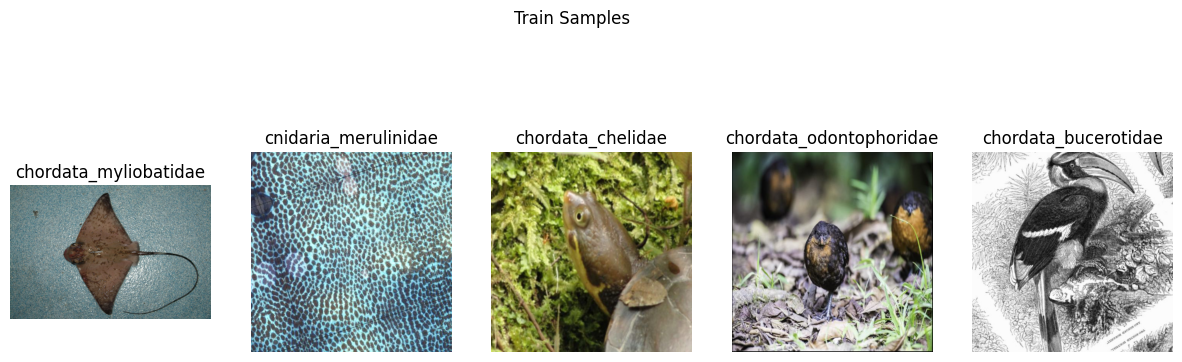

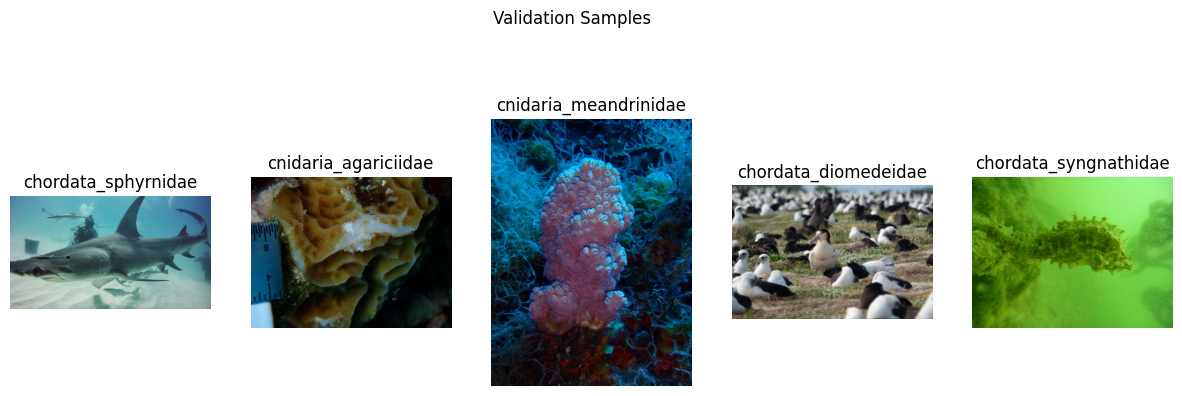

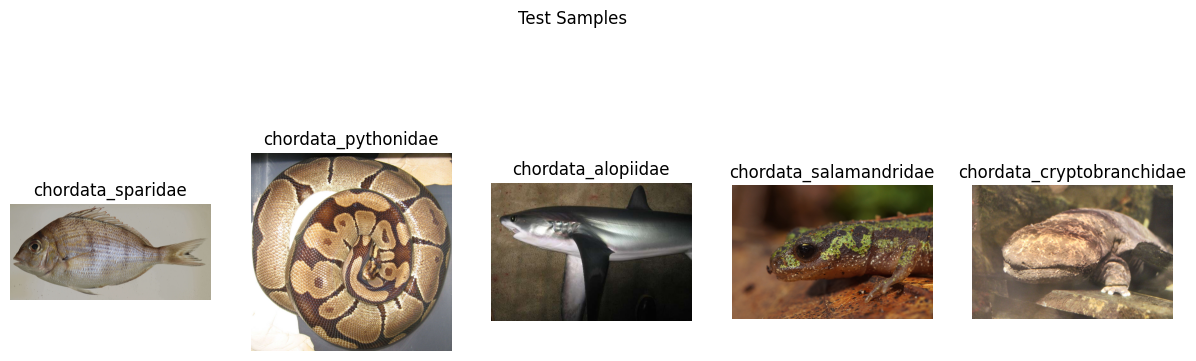

In [32]:
# Randomly display 5 images from each dataset
def plot_sample_images(df, title, n=5):
    sample_df = df.sample(n=n)
    plt.figure(figsize=(15, 5))
    for i, path in enumerate(sample_df['filepath']):
        plt.subplot(1, n, i+1)
        img = Image.open(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(sample_df.iloc[i]['original_class'])
    plt.suptitle(title)
    plt.show()

plot_sample_images(final_train_df, "Train Samples")
plot_sample_images(final_val_df, "Validation Samples")
plot_sample_images(final_test_df, "Test Samples")

## Quick exploration before encoding

Checkup: On this part we check head and tail sections of our dataframes original_class counts. As well as unique family count and sample sizes.

In [33]:
print("\nNumber of unique families:", final_train_df['original_class'].nunique())
print("Total training samples:", len(final_train_df))

print("\nNumber of unique families:", final_val_df['original_class'].nunique())
print("Total validation samples:", len(final_val_df))

print("\nNumber of unique families:", final_test_df['original_class'].nunique())
print("Total test samples:", len(final_test_df))


Number of unique families: 202
Total training samples: 45298

Number of unique families: 202
Total validation samples: 1686

Number of unique families: 202
Total test samples: 1131


In [34]:
# to see top 5 classes with most images
print("\n training data overview (head)")
print(final_train_df['original_class'].value_counts().head(5))

print("\n Validation data overview (head)")
print(final_val_df['original_class'].value_counts().head(5))

print("\n Test data Overview (head)")
print(final_test_df['original_class'].value_counts().head(5))


 training data overview (head)
original_class
chordata_plethodontidae    417
arthropoda_formicidae      395
chordata_salamandridae     391
chordata_carcharhinidae    372
chordata_dasyatidae        315
Name: count, dtype: int64

 Validation data overview (head)
original_class
chordata_dactyloidae        44
chordata_cercopithecidae    44
arthropoda_formicidae       42
chordata_salamandridae      41
chordata_plethodontidae     41
Name: count, dtype: int64

 Test data Overview (head)
original_class
chordata_cercopithecidae    29
chordata_dactyloidae        29
arthropoda_formicidae       29
chordata_salamandridae      27
chordata_plethodontidae     27
Name: count, dtype: int64


In [35]:
#to see 5 classes with least images
print("\n training data overview (tail)")
print(final_train_df['original_class'].value_counts().tail(5))

print("\n Validation data overview (tail)")
print(final_val_df['original_class'].value_counts().tail(5))

print("\n Test data Overview (tail)")
print(final_test_df['original_class'].value_counts().tail(5))


 training data overview (tail)
original_class
chordata_strigopidae       196
chordata_columbidae        196
arthropoda_palinuridae     195
chordata_phyllostomidae    195
chordata_pristidae         193
Name: count, dtype: int64

 Validation data overview (tail)
original_class
chordata_gavialidae           3
chordata_pontoporiidae        3
chordata_alligatoridae        2
chordata_brachypteraciidae    1
mollusca_conidae              1
Name: count, dtype: int64

 Test data Overview (tail)
original_class
chordata_cetorhinidae         2
chordata_rhinodermatidae      2
chordata_paradisaeidae        2
chordata_brachypteraciidae    1
chordata_pristidae            1
Name: count, dtype: int64


# 5.Preparing Custom Datasets and DataLoaders for Image Classification

In this section, we prepare our training, validation, and test datasets and also prepared the necessary data loaders to be used in a model.
1. We define custom dataset classes:
  *   SimpleDataset: For the training and validation sets. It returns both the image and its corresponding encoded label.
  *   TestDataset: For the test set, which does not have labels. It only returns the image.
2. We do basic transformations on image files:
  *   Resize all images to 224x224
  *   Convert images to PyTorch tensors so they can be used by the model.
3. Create new dataframes using custom dataset classes:
  *   train_data: using final_train_df.
  *   val_data: using final_val_df.
  *   test_data: using final_test_df.
4. Set up dataLoaders:
  *   train_loader: Loads the training data in batches of 64, shuffling the data each epoch.
  *   val_loader: Loads the validation data in batches of 64, without shuffling.
  *   test_loader: Loads the test data in batches of 64, without shuffling.

In [44]:
#for train and validation set
class SimpleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.labels = df['original_encoded'].values  # labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert('RGB') # open and convert image
        if self.transform:
            img = self.transform(img) #transform image
        return img, torch.tensor(self.labels[idx], dtype=torch.long) # return transformed image and label as tensor

class TestDataset(Dataset): # for test set (without label), rest is same
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img #just return image, not label tensor

basic_transform = transforms.Compose([   # define basic transformation
    transforms.Resize((224, 224)),   # resize images to unique size
    transforms.ToTensor(),   # transform to tensor
])

train_data = SimpleDataset(final_train_df, transform=basic_transform)  # create train_data with SimpleDataset class, using basic transform
val_data = SimpleDataset(final_val_df, transform=basic_transform)   # same for validation
test_data = TestDataset(final_test_df, transform=basic_transform)  # create test data with TestDataset class, also basic transform

BATCH_SIZE = 128 # define batch size

#divide data in batches
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)  # shuffle True so model not always learns train data in same order
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)   # shuffle False(defualt) so easy results evaluation
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE) # same as validation



Checkup: Lets test a batch to see if its working properly.

In [45]:
images, labels = next(iter(train_loader))   # first batch
print(f"Batch shape: {images.shape}") # [number of pictures in batch, number of color channels, height of image, widht of image]
print(f"Labels shape: {labels.shape}") # number of labels (64 --> 1 per image)

Batch shape: torch.Size([128, 3, 224, 224])
Labels shape: torch.Size([128])


# 6. Model Training

## 6.0 Preparing Callback Functions (EarlyStopping)

Now we define Early stopping, so the model automatically stops after a certain amount of epochs without improvement (decreasing validation loss)

In [46]:
# Define early stopping
class EarlyStopping:
    def __init__(self, patience, verbose, delta=0, path='checkpoint.pt'):  # after x times no decreasing validation loss, model will stop
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None  # to save best score so far, and later now which one was best
        self.early_stop = False # if early stop will trigger or not
        self.val_loss_min = np.inf # lowest validation loss so far
        self.delta = delta
        self.path = path  # save best model (up to this point) here

    def __call__(self, val_loss, model):
        score = -val_loss  # to compute score (lower validation loss leads to higher score)

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta: # no improvement
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience: # if patience level reached with no improvement, trigger early stop
                self.early_stop = True
        else: # if there is improvement
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model): # save the model if loss decreased
        if self.verbose:
            print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


# 6.1. Baseline Model using CNN (FamilyClassifierBaseline)

First we define the model class FamilyClassifierBaseline. we use 2 convolutional layers, each with actiavtion function ReLu and MaxPooling. First one takes input with 3 channels (RGB) and output 32 feature maps, second one takes 32 input channels and outputs 64 feature maps. After this, output is flattened and passed in fully connected layer, which maps to number of classes. No additional layers or parameters, since this is baseline model.

In [47]:
class FamilyClassifierBaseline(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierBaseline, self).__init__()

        self.conv_layers = nn.Sequential(     # first convolutional layer
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 input channels, output 32 feature maps
            nn.ReLU(),  # activation function relu
            nn.MaxPool2d(2),  # maxPooling

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # second convolutional layer
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(  # fully connected layer
            nn.Flatten(),   # flatten data
            nn.Linear(64 * 56 * 56, num_classes)  # output
        )

    def forward(self, x):  # define order of model, first data goes through convolutional layers, then fully connected
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [48]:
num_classes = final_train_df['original_encoded'].nunique() # get number of unique classes
model = FamilyClassifierBaseline(num_classes) # define model with number of classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function as cross entropy for multiclass classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer adam and learning rate (most common ones, since baseline model)


Now we will train the model, with 10 epochs

In [49]:
EPOCHS = 10 # number of epochs
early_stopping = EarlyStopping(patience=4, verbose=True, path='best_model_baseline.pt') # create the early stopping, with patience 4

#to save the loss and accuracy values, for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS): # train each epoch
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset the statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move the batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() # reset previous gradients
        loss.backward() # backpropragation
        optimizer.step() # update parameters of model

        #update training statistics
        train_loss += loss.item() * images.size(0)
        n, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss /= train_total # average train loss and acuracy
    train_acc = train_correct / train_total

    model.eval() # set to evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    #batch wise validation
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    #for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    #output current performance from this epoch
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)


    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") # if early stopping, stop the loop
        break


Epoch 1/10 | Train Loss: 4.3045 | Train Acc: 0.1733 | Val Loss: 4.5730 | Val Acc: 0.1305
Validation loss decreased (inf --> 4.572974). Saving model...


Epoch 2/10 | Train Loss: 1.8452 | Train Acc: 0.5981 | Val Loss: 5.3769 | Val Acc: 0.1471
EarlyStopping counter: 1 out of 4


Epoch 3/10 | Train Loss: 0.5392 | Train Acc: 0.8788 | Val Loss: 7.6752 | Val Acc: 0.1495
EarlyStopping counter: 2 out of 4


Epoch 4/10 | Train Loss: 0.1753 | Train Acc: 0.9608 | Val Loss: 9.2572 | Val Acc: 0.1536
EarlyStopping counter: 3 out of 4


KeyboardInterrupt: 

Now we add some visualizations to evaluate our model performance

In [ ]:
#plot the accurarcy and loss over time
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('Loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [ ]:
model.load_state_dict(torch.load('best_model_baseline.pt'))  # use best model
model.to(device)
model.eval()

# true labels and predictions
y_true = []
y_pred = []

with torch.no_grad():  # no gradient needed
    label_index = 0  # very important
    for images in test_loader:  # only images, not (images, labels)
        images = images.to(device)

        outputs = model(images)  # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend true labels manually from final_test_df
        true_labels_batch = true_labels[label_index : label_index + batch_size]
        y_true.extend(true_labels_batch)

        label_index += batch_size

# calculate macro f1
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
model.load_state_dict(torch.load('best_model_baseline.pt'))  # use the best model and not the last one (possible because early stopping class)
model.to(device)
model.eval() # into evaluation mode

all_paths = final_test_df['filepath'].tolist() # all image filepaths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for the accuracies
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist() # make true labels to list
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")


In [ ]:
#convert predictions in csv, to export them
result_df_baseline = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df.to_csv("test_predictions_baseline.csv", index=False) # save as csv

In the end, we show the classes that made up the biggest parts of predictions

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_baseline['top1_match'])

total_preds = len(result_df_baseline)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent_of_all_predictions'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

we see that class number x was the predicted class in xx% of the time, and then a lot of classes have make up y% or lower each

# 6.2.  Improved Model Based on Baseline CNN Model (FamilyClassifierTunedv1)

We try a upgraded version of this baseline model now, with some more advanced tunings and layers.

In [ ]:
class FamilyClassifierTunedv1(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierTunedv1, self).__init__()

        #three convolutional blocks
        self.conv_layers = nn.Sequential(  # we have 3 convolutional layers,
            #input channels 3 (RGB), output 32 feature maps
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #32 input channels, output 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #input 64, output 128 feature maps
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )


        self.fc_layers = nn.Sequential(   #fully connected layer
            nn.Flatten(), # flatten data (to 1D)
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # we use dropout for regularization
            nn.Linear(512, num_classes) #output layer, based on number of classes
        )

    def forward(self, x): # pass through layers
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [ ]:
num_classes = final_train_df['original_encoded'].nunique() # number of unique classes
model = FamilyClassifierTunedv1(num_classes) # define model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # optimizer adam with smaller learning rate this time

In [ ]:
EPOCHS = 15 # number of epochs, 15 this time
early_stopping = EarlyStopping(patience=6, verbose=1, path='best_model_advanced.pt') # higher patience this time because of more epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) #reduce the learning rate (by factor 0.5) if validation loss does not improve for 3 epochs

#for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train() # train the model
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() #reset previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update parameters of model

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    #average loss and accurarcy
    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval() # evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    with torch.no_grad(): # no gradient needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # move batch to gpu/cpu
            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) #calculate loss

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    #average loss and accuraccy
    val_loss /= val_total
    val_acc = val_correct / val_total

    # for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)

    # Scheduler step (neccesary to dynamically reduce learning rate or not)
    scheduler.step(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") #if early stopping triggered
        break

Now again the visualizations/analysies

In [ ]:
# plot accuracy and loss
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train accuracy')
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [ ]:
# get macro f1 score as metric (better for unbalanced classes)

model.load_state_dict(torch.load('best_model_advanced.pt'))  # use the best model and not the last one (possible because early stopping class)
model.to(device)
model.eval()

# true labels and predictions
y_true = []
y_pred = []

with torch.no_grad():  # no gradient needed
    label_index = 0  # very important
    for images in test_loader:  # only images, not (images, labels)
        images = images.to(device)

        outputs = model(images)  # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend true labels manually from final_test_df
        true_labels_batch = true_labels[label_index : label_index + batch_size]
        y_true.extend(true_labels_batch)

        label_index += batch_size

# calculate macro f1
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")


We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
model.load_state_dict(torch.load('best_model_advanced.pt'))  # use best model, not last one (because early stopping class possible)
model.to(device)
model.eval()


all_paths = final_test_df['filepath'].tolist() # get all image paths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for top 3 accuracy
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"Top 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")


In [ ]:
#convert predictions in csv
result_df_advancedv1 = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df.to_csv("test_predictions_advancedv1.csv", index=False) # save to csv

In the end, we show the classes that made up the biggest parts of predictions

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_advancedv1['top1_match'])

total_preds = len(result_df_advancedv1)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

# 6.3.  More complex CNN Model (FamilyClassifierTunedv2)

Now we try a final and even more advanced model, with 4 convolutional layers, batch normalization after each of them and 2 dense layers

In [ ]:
class FamilyClassifierTunedv2(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierTunedv2, self).__init__()

        self.conv_layers = nn.Sequential(
            # first convolutional layer
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 input channels RGB, 32 feature maps output
            nn.BatchNorm2d(32), # normalize outputs from layer
            nn.ReLU(), # activation function Relu
            nn.MaxPool2d(2), # maxpooling

            #second convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 input channels, 64 output feature maps
            nn.BatchNorm2d(64), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),

            #third convolutional layer
            nn.Conv2d(64, 128, kernel_size=3, padding=1), #64 input channels, 128 output feature maps
            nn.BatchNorm2d(128), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),

            #fourth convolutional layer
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 128 input channels, 256 output feature maps
            nn.BatchNorm2d(256), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(   # two fully connected layers
            nn.Flatten(), # flatten data
            nn.Linear(256 * 14 * 14, 1024), # first dense layer
            nn.ReLU(),
            nn.Dropout(0.4),  # stronger regulization
            nn.Linear(1024, 512), # second dense layer
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes) # output layer
        )

    def forward(self, x): # for forward pass
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [ ]:
num_classes = final_train_df['original_encoded'].nunique() # number of unique classes
model = FamilyClassifierTunedv2(num_classes) # define model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # optimizer adam and learning rate

In [ ]:
EPOCHS = 30 # number of epochs, 15 this time
early_stopping = EarlyStopping(patience=6, verbose=1, path='best_model_advancedv2.pt') # higher patience this time because of more epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) #reduce the learning rate (by factor 0.5) if validation loss does not improve for 3 epochs

#for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train() # train the model
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() #reset previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update parameters of model

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    #average loss and accurarcy
    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval() # evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    with torch.no_grad(): # no gradient needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # move batch to gpu/cpu
            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) #calculate loss

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    #average loss and accuraccy
    val_loss /= val_total
    val_acc = val_correct / val_total

    # for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)

    # Scheduler step (neccesary to dynamically reduce learning rate or not)
    scheduler.step(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") #if early stopping triggered
        break

Now again the visualizations/analysies

In [ ]:
# plot accuracy and loss
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train accuracy')
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [ ]:
# get macro f1 score as metric (better for unbalanced classes)

model.load_state_dict(torch.load('best_model_advancedv2.pt'))  # use the best model and not the last one (possible because early stopping class)
model.to(device)
model.eval()

# true labels and predictions
y_true = []
y_pred = []

with torch.no_grad():  # no gradient needed
    label_index = 0  # very important
    for images in test_loader:  # only images, not (images, labels)
        images = images.to(device)

        outputs = model(images)  # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend true labels manually from final_test_df
        true_labels_batch = true_labels[label_index : label_index + batch_size]
        y_true.extend(true_labels_batch)

        label_index += batch_size

# calculate macro f1
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")


We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
model.load_state_dict(torch.load('best_model_advancedv2.pt'))  # use best model, not last one (because early stopping class possible)
model.to(device)
model.eval()


all_paths = final_test_df['filepath'].tolist() # get all image paths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for top 3 accuracy
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"Top 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")


In [ ]:
#convert predictions in csv
result_df_advancedv2 = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df.to_csv("test_predictions_advancedv2.csv", index=False) # save to csv

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_advancedv2['top1_match'])

total_preds = len(result_df_advancedv2)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

# 6.4. Pretrained Model ResNet50 (FamilyClassifierResNet50)

In [ ]:
num_classes = final_train_df['original_encoded'].nunique()

In [ ]:
# RESNET50 Model
resnet50_model = models.resnet50(pretrained=True)
num_ftrs = resnet50_model.fc.in_features
resnet50_model.fc = nn.Linear(num_ftrs, num_classes)
resnet50_model = resnet50_model.to(device)

In [ ]:
# ResNet50 Training Setup
criterion = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet50_model.parameters(), lr=0.0005)
scheduler_resnet = ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.5, patience=5)
early_stopping_resnet = EarlyStopping(patience=6, verbose=True, path='best_model_resnet50.pt')

EPOCHS = 15

train_losses_resnet = []
val_losses_resnet = []
train_accuracies_resnet = []
val_accuracies_resnet = []

for epoch in range(EPOCHS):
    resnet50_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f'ResNet50 - Epoch [{epoch+1}/{EPOCHS}]', leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet50_model(images)
        loss = criterion(outputs, labels)

        optimizer_resnet.zero_grad()
        loss.backward()
        optimizer_resnet.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss /= train_total
    train_acc = train_correct / train_total

    resnet50_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accuracies_resnet.append(train_acc)
    val_accuracies_resnet.append(val_acc)

    print(f"ResNet50 - Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    early_stopping_resnet(val_loss, resnet50_model)
    scheduler_resnet.step(val_loss)

    if early_stopping_resnet.early_stop:
        print(f"Early stopping triggered for ResNet50 at epoch {epoch+1}")
        break

In [ ]:
# plot accuracy and loss
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train accuracy')
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses_resnet, val_losses_resnet, train_accuracies_resnet, val_accuracies_resnet)


In [ ]:
# Evaluate ResNet50
print("\nEvaluating ResNet50 on Test Set")
resnet50_model.load_state_dict(torch.load('best_model_resnet50.pt'))
resnet50_model.eval()

all_paths = final_test_df['filepath'].tolist()
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = resnet50_model(images)
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1)

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop-1 Accuracy (ResNet50): {top1_correct / total:.4f}")
print(f"Top-3 Accuracy (ResNet50): {top3_correct / total:.4f}")

In [ ]:
# Save ResNet Test Predictions to CSV
result_df_resnet = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df.to_csv("test_predictions_resnet.csv", index=False)


print(top1_summary.head(10))

In [ ]:
# VGG16 Most Predicted Classes Summary
top1_counts = Counter(result_df_resnet['top1_match'])
total_preds = len(result_df_resnet)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)


# 6.4. Pretrained Model VGG16 (FamilyClassifierVGG16)

In [ ]:
# VGG16 Model
vgg16_model = models.vgg16(pretrained=True)
num_ftrs = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_ftrs, num_classes)
vgg16_model = vgg16_model.to(device)

In [ ]:
# VGG16 Training Setup
criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = torch.optim.Adam(vgg16_model.parameters(), lr=0.0005)
scheduler_vgg = ReduceLROnPlateau(optimizer_vgg, mode='min', factor=0.5, patience=5)
early_stopping_vgg = EarlyStopping(patience=6, verbose=True, path='best_model_vgg16.pt')

EPOCHS = 15

train_losses_vgg = []
val_losses_vgg = []
train_accuracies_vgg = []
val_accuracies_vgg = []

for epoch in range(EPOCHS):
    vgg16_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f'VGG16 - Epoch [{epoch+1}/{EPOCHS}]', leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = vgg16_model(images)
        loss = criterion_vgg(outputs, labels)

        optimizer_vgg.zero_grad()
        loss.backward()
        optimizer_vgg.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss /= train_total
    train_acc = train_correct / train_total

    vgg16_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16_model(images)
            loss = criterion_vgg(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses_vgg.append(train_loss)
    val_losses_vgg.append(val_loss)
    train_accuracies_vgg.append(train_acc)
    val_accuracies_vgg.append(val_acc)

    print(f"VGG16 - Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    early_stopping_vgg(val_loss, vgg16_model)
    scheduler_vgg.step(val_loss)

    if early_stopping_vgg.early_stop:
        print(f"Early stopping triggered for VGG16 at epoch {epoch+1}")
        break

# VGG16 Training Curve Plot
plot_training_curves(train_losses_vgg, val_losses_vgg, train_accuracies_vgg, val_accuracies_vgg)



In [ ]:
# Evaluate VGG16 on Test Set
print("\nEvaluating VGG16 on Test Set")
vgg16_model.load_state_dict(torch.load('best_model_vgg16.pt'))
vgg16_model.eval()

all_paths = final_test_df['filepath'].tolist()
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = vgg16_model(images)
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1)

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop-1 Accuracy (VGG16): {top1_correct / total:.4f}")
print(f"Top-3 Accuracy (VGG16): {top3_correct / total:.4f}")

In [ ]:
# Save VGG16 Test Predictions to CSV
result_df_vgg = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df.to_csv("test_predictions_vgg16.csv", index=False)


print(top1_summary.head(10))

In [ ]:
# VGG16 Most Predicted Classes Summary
top1_counts = Counter(result_df_vgg['top1_match'])
total_preds = len(result_df_vgg)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)
